# 3. A sodium ionomer with and without smeared electrostatics

A precise polyethylene-acrylate ionomer (one `-CH2-CH(CH2COO-)-CH2-` block every
15 backbone carbons) with its Na+ counterions, initialized twice from the
same placement: with the default protocol (no charges during DPD), and with
FlowerMD's optional smeared Coulomb term, where each charge is a Gaussian
cloud so opposite charges can pass through each other without diverging.

The counterions are placed on lattice sites like every other unit, not next
to the carboxylates, so any pairing comes from the interactions. We compare
the ion aggregates (Na+ linked to carboxylates within 3 Å) right after
initialization and after the Sage minimization that follows.

The paper-scale version of this comparison (200 chains, 71,800 atoms, three
seeds, two smearing widths) is the experiment
`electrostatics-during-initialization__smeared-charges-on-sodium-ionomer`.
This notebook uses 40 chains; it runs in minutes on a GPU.

Exported residues are `ETH` (ethylene), `ACR` (acrylate) and `NA`; each
condition writes its structures to its own folder.

In [1]:
import hoomd

# GPU if one is visible, otherwise CPU. OpenMM follows the same choice.
try:
    DEVICE = hoomd.device.GPU()
    OPENMM_PLATFORM = "CUDA"
except Exception:
    DEVICE = hoomd.device.CPU()
    OPENMM_PLATFORM = "CPU"
print(DEVICE, OPENMM_PLATFORM)

<hoomd.device.CPU object at 0x7a4354110ad0> CPU


In [2]:
# The frozen all-atom PhantomWalk protocol, written out explicitly.
PROTOCOL = dict(
    bonded="uff", A=1250.0, gamma=200.0, kT=1.0, r_cut=3.5, bonded_scale=30.0,
    epsilon_weighting=True, protect_stereochemistry=True, stereo_k=30000.0,
)
RUN = dict(
    dpd_min_steps=3500, dpd_chunk=500, dpd_max_steps=40000, energy_tol=0.02,
    consecutive=2, dpd_samples_per_chunk=5, fire_steps=100, fire_dt=0.001,
    require_convergence=False,
)
DT = 0.001

In [3]:
from pathlib import Path

# Everything this notebook writes goes here.
OUT = Path("outputs/3-sodium-ionomer")
OUT.mkdir(parents=True, exist_ok=True)

# True saves a DPD + FIRE trajectory (one GSD frame every 250 steps) for a
# movie; False writes only the starting frame.
SAVE_TRAJECTORY = True


def writers(folder):
    """Simulation keywords that put the GSD trajectory and log in `folder`."""
    folder.mkdir(parents=True, exist_ok=True)
    return dict(
        gsd_file_name=str(folder / "dpd.gsd"),
        gsd_write_freq=250 if SAVE_TRAJECTORY else 10**9,
        log_file_name=str(folder / "log.txt"),
    )

In [4]:
import mbuild as mb
import numpy as np
import unyt as u
from flowermd.library import AllAtomDPD, AllAtomLattice, AllAtomPhantomWalk, PEAAIonomer
from phantomwalk.all_atom import ion_sites, ion_structure, sage_handoff

chains = PEAAIonomer(lengths=7, num_mols=40, pattern="EEAEE", tacticity="atactic", seed=5)
sodium = chains.counterions("[Na+]")
system = AllAtomLattice([chains, sodium], density=0.85 * u.g / u.cm**3, unit="repeat", seed=5)
ions, carboxylates = ion_sites(system.system, counterion="Na")
print(f"{system.system.n_particles} atoms, {len(ions)} Na+, {len(carboxylates)} carboxylates")

2026-09-24 14:05:01,410 - mbuild.compound - WARNING - Compound.box.lengths < Compound.boundingbox.lengths. There may be particles outside of the defined simulation box.


14360 atoms, 280 Na+, 280 carboxylates


In [5]:
ELECTROSTATICS = {
    "coulomb off": dict(),
    "smeared coulomb": dict(charges="nagl", electrostatics="smeared",
                            charge_smearing=2.0, charge_scale=1.0, pppm_order=5),
}
CUTOFF_A = 3.0
results = {}
for label, extra in ELECTROSTATICS.items():
    folder = OUT / label.replace(" ", "-")
    ff = AllAtomDPD(system.system, **PROTOCOL, **extra)
    box_a = np.asarray(ff.frame.configuration.box[:3])
    sim = AllAtomPhantomWalk.from_system(system, forcefield=ff, dt=DT, device=DEVICE, seed=5,
                                         **writers(folder))
    record = sim.run_initialization(**RUN)
    initialized = ion_structure(sim.final_positions() * 10, box_a, ions, carboxylates, CUTOFF_A)
    # to_compound() writes into the compound it is given; a clone keeps the
    # shared placement untouched for the next condition
    handoff, minimized_a = sage_handoff(sim.to_compound(mb.clone(system.system)), box_a / 10,
                                        platform=OPENMM_PLATFORM)
    minimized = ion_structure(minimized_a, box_a, ions, carboxylates, CUTOFF_A)
    results[label] = dict(record=record, initialized=initialized, minimized=minimized,
                          handoff=handoff, sim=sim, ff=ff, minimized_a=minimized_a,
                          folder=folder)
    print(f"{label}: DPD {record['dpd_steps']} steps in {record['timings_s']['dpd']:.0f} s, "
          f"energy removed {handoff['energy_removed_sage_epsilon_atom']:.2f} eps_max/atom")

*Warning*: dihedral.harmonic: specified K <= 0


*Warning*: dihedral.harmonic: specified K <= 0


*Warning*: dihedral.harmonic: specified K <= 0


*Warning*: dihedral.harmonic: specified K <= 0


/home/joelaforet/miniconda3/envs/phantomwalk-all-atom/lib/python3.12/site-packages/flowermd/utils/actions.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  eta = np.round((self.n_steps - current_step) / (60 * tps), 1)
/home/joelaforet/miniconda3/envs/phantomwalk-all-atom/lib/python3.12/site-packages/flowermd/utils/actions.py:22: RuntimeWarning: invalid value encountered in scalar floor_divide
  eta_hour = eta // 60
/home/joelaforet/miniconda3/envs/phantomwalk-all-atom/lib/python3.12/site-packages/flowermd/utils/actions.py:23: RuntimeWarning: invalid value encountered in scalar remainder
  eta_min = np.round(eta % 60, 0)


...

*Warning*: dihedral.harmonic: specified K <= 0


*Warning*: dihedral.harmonic: specified K <= 0


*Warning*: charge.pppm: system is not neutral and unscreened interactions are calculated, the net charge is 0.000371933


notice(2): charge.pppm: RMS error: 0.00271995


smeared coulomb: DPD 23000 steps in 1036 s, energy removed 17.88 eps_max/atom


In [6]:
print(f"{'':>16} {'stage':>11} {'free Na+':>9} {'aggregates':>11} {'largest':>8} {'ion-weighted mean':>18}")
for label, r in results.items():
    for stage in ("initialized", "minimized"):
        s = r[stage]
        print(f"{label:>16} {stage:>11} {s['free_ion_fraction']:9.2f} {s['n_aggregates']:11d} "
              f"{s['largest_aggregate']:8d} {s['ion_weighted_mean_size']:18.2f}")

                       stage  free Na+  aggregates  largest  ion-weighted mean
     coulomb off initialized      0.83         272        2               1.06
     coulomb off   minimized      0.00          54       24              10.97
 smeared coulomb initialized      0.75         267        6               1.17
 smeared coulomb   minimized      0.00          61       59              18.41


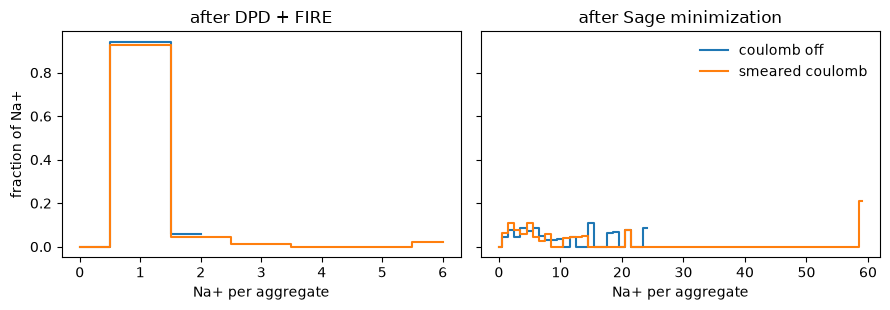

In [7]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
if plt is not None:
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
    for ax, stage in zip(axes, ("initialized", "minimized")):
        for label, r in results.items():
            frac = np.asarray(r[stage]["ion_fraction_by_size"])
            ax.step(np.arange(len(frac)), frac, where="mid", label=label)
        ax.set_xlabel("Na+ per aggregate")
        ax.set_title(f"after {stage.replace('initialized', 'DPD + FIRE').replace('minimized', 'Sage minimization')}")
    axes[0].set_ylabel("fraction of Na+")
    axes[1].legend(frameon=False)
    fig.tight_layout()

Which aggregate distribution is *right* needs an equilibrated reference (long
MD at high temperature); what this shows is that the initializer's choice of
interactions changes the ion structure a user starts from, at the cost of one
PPPM term during DPD.

## Export both conditions

`residue_topology` reads the FlowerMD hierarchy (melt, molecule, monomer)
into PDB labels: one residue per monomer, one segment ID per molecule (four
base-36 characters, up to 1.68 million molecules), CONECT records for every
bond and the box in CRYST1. Molecules are written whole with their centroids
in the box, so per-chain quantities such as Rg work directly. Three stages
are written:

| file | coordinates |
|---|---|
| `placement.pdb` | the lattice placement before DPD |
| `initialized.pdb` | after DPD + FIRE, what `sim.to_compound()` hands off |
| `minimized.pdb` | after the Sage 2.3.0 minimization; **use this one for analysis** |

`dpd.dcd` is the DPD + FIRE trajectory (whole, continuous molecules) with
`initialized.pdb` as its topology; `movie.pml` and `minimized.pml` open them
in PyMOL (`cd` into the output folder, then `pymol movie.pml`).

Each condition has its own folder, `outputs/3-sodium-ionomer/coulomb-off`
and `.../smeared-coulomb`. Na+ ions have no bonds, so the views and the
PyMOL scripts draw them as spheres.

In [8]:
from phantomwalk.all_atom import (
    flush_trajectory, frame_positions, residue_topology, write_pdb, write_trajectory,
)
from phantomwalk.all_atom.visualization import write_pymol_script


def export(folder, sim, ff, minimized_a):
    """Write the three stages, the DPD trajectory and the PyMOL scripts."""
    top = residue_topology(sim.system.system, box_a=ff.frame.configuration.box[:3])
    initialized_a = sim.final_positions() * 10
    write_pdb(top, frame_positions(ff.frame), folder / "placement.pdb")
    write_pdb(top, initialized_a, folder / "initialized.pdb")
    write_pdb(top, minimized_a, folder / "minimized.pdb")
    flush_trajectory(sim)
    # FIRE's last steps rarely land on the GSD period; append the final frame
    write_trajectory(top, folder / "dpd.gsd", folder / "dpd.dcd",
                     append_positions_a=initialized_a)
    write_pymol_script(folder / "initialized.pdb", folder / "movie.pml",
                       trajectory=folder / "dpd.dcd", color_by="resn")
    write_pymol_script(folder / "minimized.pdb", folder / "minimized.pml", color_by="resn")
    return top

for label, r in results.items():
    top = export(r["folder"], r["sim"], r["ff"], r["minimized_a"])
    print(f"{label}: {sorted(set(top.resnames))} -> {r['folder']}")

coulomb off: ['ACR', 'ETH', 'NA'] -> outputs/3-sodium-ionomer/coulomb-off


smeared coulomb: ['ACR', 'ETH', 'NA'] -> outputs/3-sodium-ionomer/smeared-coulomb


## Look at it

NGLView draws every atom as licorice and keeps only the CONECT bonds (NGL
would otherwise guess bonds between atoms that overlap during DPD).
`color="chainname"` gives one color per molecule, `"resname"` one per residue
name, `"element"` the usual element colors. The movie needs
`SAVE_TRAJECTORY = True`; `save_gif(movie, n_frames, "dpd.gif")` records it
from a live notebook.

In [9]:
from phantomwalk.all_atom.visualization import save_gif, show_movie, show_structure

show_structure(results["smeared coulomb"]["folder"] / "minimized.pdb", color="resname",
               spheres="[NA]")

In [10]:
folder = results["smeared coulomb"]["folder"]
movie = (show_movie(folder / "initialized.pdb", folder / "dpd.dcd", color="resname",
                    spheres="[NA]") if SAVE_TRAJECTORY else None)
movie

/home/joelaforet/miniconda3/envs/phantomwalk-all-atom/lib/python3.12/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"
